# 10 — Applications: Filtering, Deconvolution, Diffraction, and Crystallography

## Learning goals

- Remove an unwanted frequency with a notch filter.
- Recover a blurred signal using deconvolution.
- Understand Fraunhofer diffraction as a Fourier transform of an aperture.
- Simulate a toy crystallography pattern from electron density.

## Mental model

Fourier analysis becomes useful when physics or measurement acts separately on each frequency. Filtering edits frequencies. Deconvolution divides out a measuring device. Diffraction lets nature compute a Fourier transform for us.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 4.8)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

def stem_spectrum(freqs, values, title="Spectrum", xlabel="Frequency", ylabel="Amplitude"):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    markerline, stemlines, baseline = ax.stem(freqs, values, basefmt=" ")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True)
    plt.show()

## Application 1: remove a hum frequency

If a signal contains an unwanted sinusoidal component, the Fourier transform lets us identify and remove its frequency.

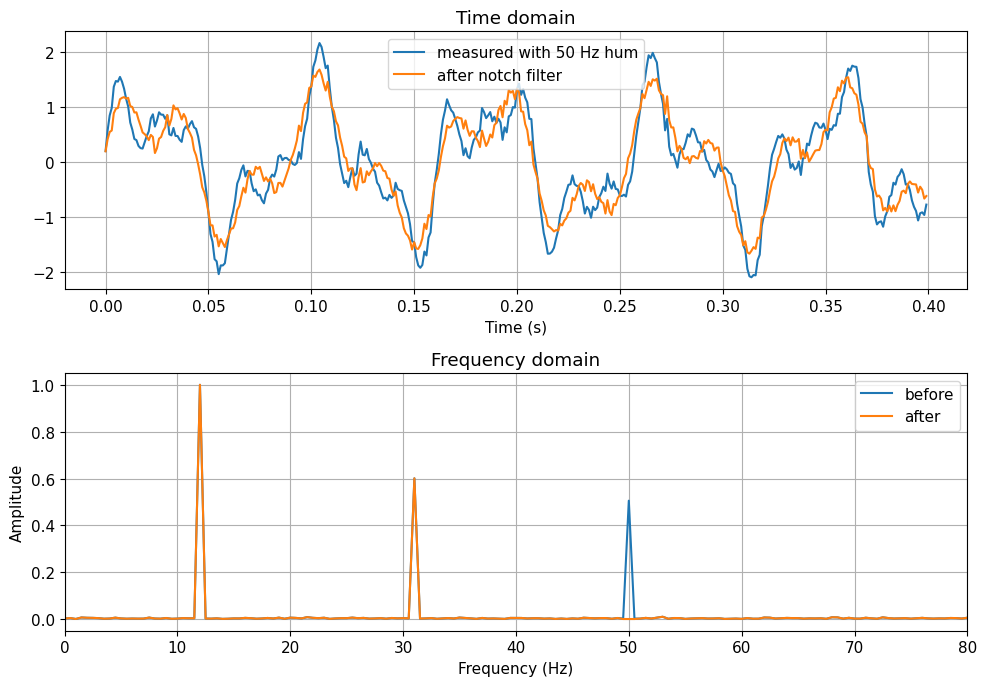

In [2]:
R = 1000
T = 2
N = R*T
t = np.arange(N)/R
rng = np.random.default_rng(1)

clean = np.sin(2*np.pi*12*t) + 0.6*np.sin(2*np.pi*31*t + 0.3)
hum = 0.5*np.sin(2*np.pi*50*t)
measured = clean + hum + 0.08*rng.normal(size=N)

X = np.fft.rfft(measured)
freq = np.fft.rfftfreq(N, d=1/R)
notch = np.ones_like(X, dtype=float)
notch[np.abs(freq-50) < 1.0] = 0
filtered = np.fft.irfft(X*notch, n=N)

fig, axs = plt.subplots(2, 1, figsize=(10, 7))
axs[0].plot(t[:400], measured[:400], label="measured with 50 Hz hum")
axs[0].plot(t[:400], filtered[:400], label="after notch filter")
axs[0].set_title("Time domain")
axs[0].set_xlabel("Time (s)")
axs[0].legend()
axs[1].plot(freq, 2*np.abs(X)/N, label="before")
axs[1].plot(freq, 2*np.abs(X*notch)/N, label="after")
axs[1].set_xlim(0, 80)
axs[1].set_title("Frequency domain")
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_ylabel("Amplitude")
axs[1].legend()
plt.tight_layout()
plt.show()

## Application 2: deconvolution

A measuring device often smears the true signal by convolution with an impulse response function $h$:

$$y = x*h + \eta.$$

In the Fourier domain,

$$Y = XH + N.$$

A stable approximate inverse is the Wiener-style filter

$$\hat X = \frac{H^*}{|H|^2 + K}Y,$$

where $K$ prevents division by tiny noisy values.

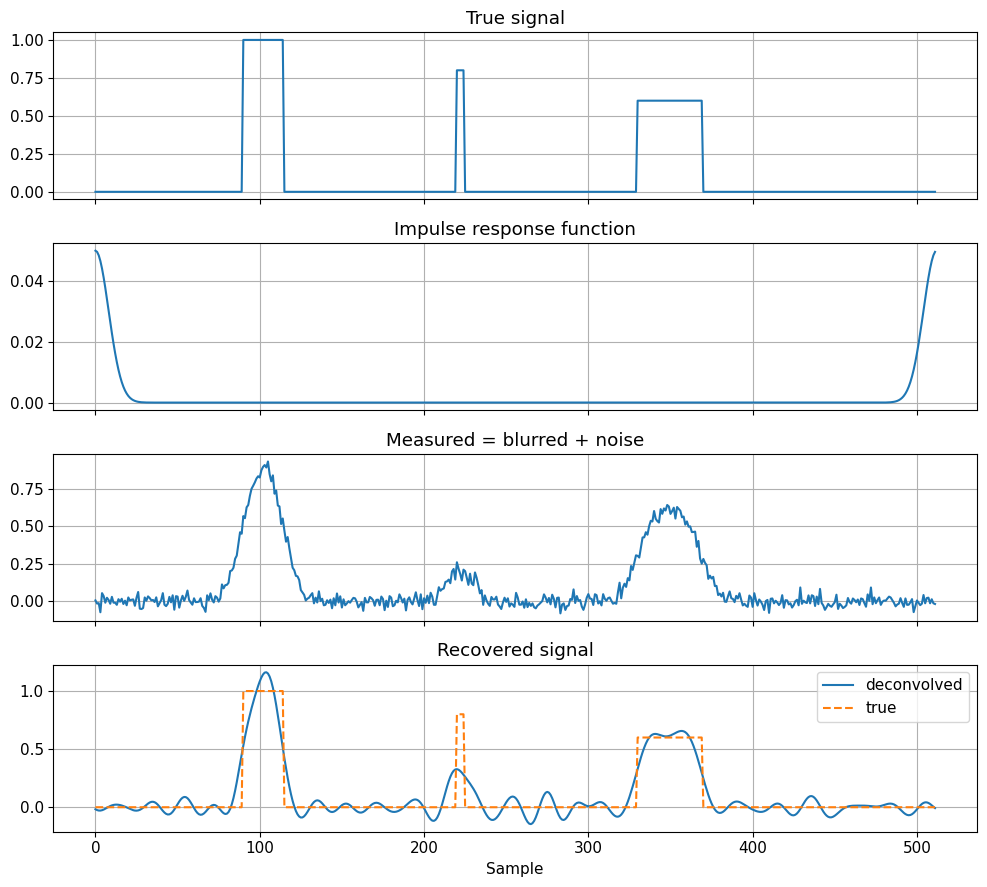

In [3]:
N = 512
n = np.arange(N)
true = np.zeros(N)
true[90:115] = 1.0
true[220:225] = 0.8
true[330:370] = 0.6

# Gaussian impulse response, centered for circular convolution
sigma = 8
d = np.minimum(n, N-n)
h = np.exp(-d**2/(2*sigma**2))
h /= h.sum()

H = np.fft.fft(h)
Y_clean = np.fft.ifft(np.fft.fft(true)*H).real
noise = 0.03*np.random.default_rng(2).normal(size=N)
measured = Y_clean + noise
Y = np.fft.fft(measured)

K = 0.003
X_wiener = np.conj(H)/(np.abs(H)**2 + K) * Y
recovered = np.fft.ifft(X_wiener).real

fig, axs = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
axs[0].plot(n, true)
axs[0].set_title("True signal")
axs[1].plot(n, h)
axs[1].set_title("Impulse response function")
axs[2].plot(n, measured)
axs[2].set_title("Measured = blurred + noise")
axs[3].plot(n, recovered, label="deconvolved")
axs[3].plot(n, true, "--", label="true")
axs[3].set_title("Recovered signal")
axs[3].set_xlabel("Sample")
axs[3].legend()
plt.tight_layout()
plt.show()

## Application 3: Fraunhofer diffraction from a slit

A slit aperture is a rectangular function. In far-field diffraction, the field pattern is the Fourier transform of the aperture. The transform of a rectangle is a sinc function, and the intensity is the squared magnitude.

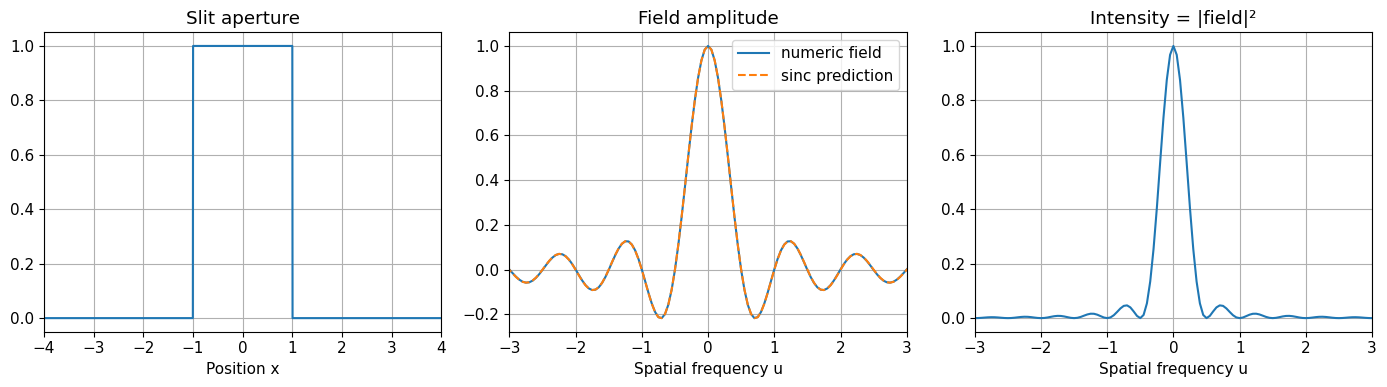

In [4]:
N = 4096
x = np.linspace(-10, 10, N)
dx = x[1]-x[0]

def aperture(width):
    return (np.abs(x) < width/2).astype(float)

def diffraction(ap):
    G = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(ap))) * dx
    u = np.fft.fftshift(np.fft.fftfreq(N, d=dx))
    intensity = np.abs(G)**2
    intensity /= intensity.max()
    return u, G, intensity

width = 2.0
ap = aperture(width)
u, G, I = diffraction(ap)

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
axs[0].plot(x, ap)
axs[0].set_xlim(-4, 4)
axs[0].set_title("Slit aperture")
axs[0].set_xlabel("Position x")
axs[1].plot(u, G.real/G.real.max(), label="numeric field")
axs[1].plot(u, np.sinc(width*u), "--", label="sinc prediction")
axs[1].set_xlim(-3, 3)
axs[1].set_title("Field amplitude")
axs[1].set_xlabel("Spatial frequency u")
axs[1].legend()
axs[2].plot(u, I)
axs[2].set_xlim(-3, 3)
axs[2].set_title("Intensity = |field|²")
axs[2].set_xlabel("Spatial frequency u")
plt.tight_layout()
plt.show()

## Slit width controls diffraction width

A wider slit gives a narrower central diffraction peak. This is another expression of the reciprocal-width tradeoff.

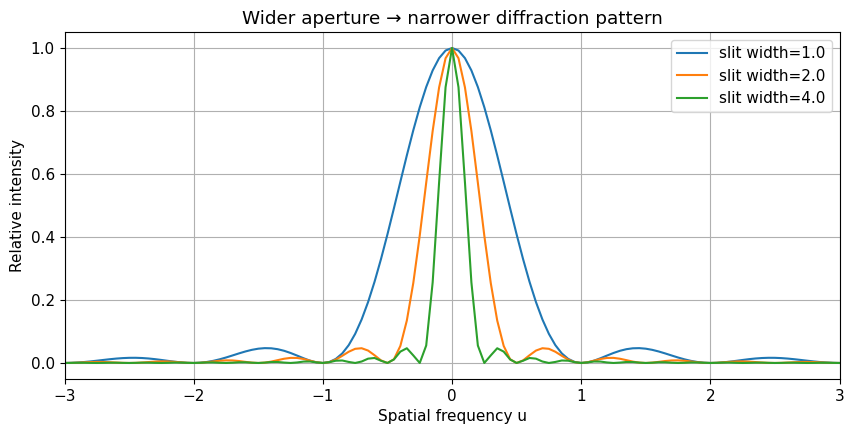

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for width in [1.0, 2.0, 4.0]:
    u, G, I = diffraction(aperture(width))
    ax.plot(u, I, label=f"slit width={width}")
ax.set_xlim(-3, 3)
ax.set_title("Wider aperture → narrower diffraction pattern")
ax.set_xlabel("Spatial frequency u")
ax.set_ylabel("Relative intensity")
ax.legend()
plt.show()

## Application 4: toy crystallography

A crystal's electron density acts like a structured aperture for X-rays. Its diffraction pattern is related to the magnitude of its Fourier transform.

In this toy example we keep the complex phase, so the inverse transform can recover the density. Real crystallography must solve an additional phase-recovery problem.

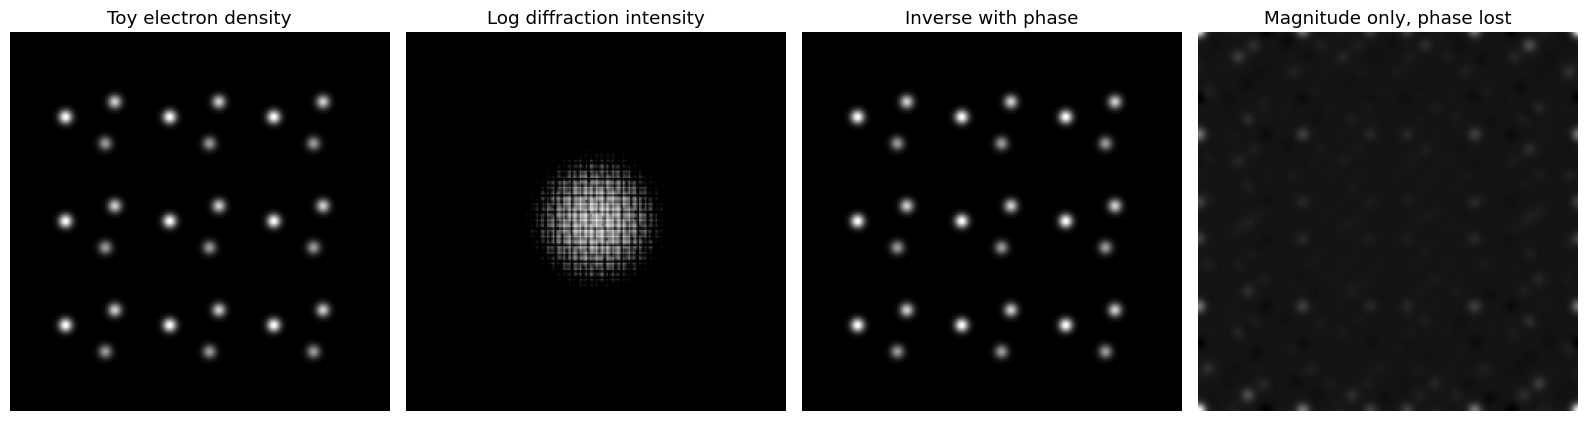

In [6]:
N = 256
y, x = np.mgrid[-1:1:complex(N), -1:1:complex(N)]

def gaussian_dot(x0, y0, sigma=0.035, amp=1.0):
    return amp*np.exp(-((x-x0)**2 + (y-y0)**2)/(2*sigma**2))

# A small repeated motif: a toy electron-density map
motif = [(-0.16, 0.00, 1.0), (0.10, 0.08, 0.8), (0.05, -0.14, 0.6)]
density = np.zeros((N, N))
for cx in [-0.55, 0.0, 0.55]:
    for cy in [-0.55, 0.0, 0.55]:
        for dx0, dy0, amp in motif:
            density += gaussian_dot(cx+dx0, cy+dy0, sigma=0.025, amp=amp)

density /= density.max()
F = np.fft.fft2(density)
diffraction = np.log1p(np.abs(np.fft.fftshift(F))**2)
recovered = np.fft.ifft2(F).real
intensity_only_bad = np.fft.ifft2(np.abs(F)).real

fig, axs = plt.subplots(1, 4, figsize=(16, 4.2))
axs[0].imshow(density, cmap="gray", origin="lower")
axs[0].set_title("Toy electron density")
axs[1].imshow(diffraction, cmap="gray", origin="lower")
axs[1].set_title("Log diffraction intensity")
axs[2].imshow(recovered, cmap="gray", origin="lower")
axs[2].set_title("Inverse with phase")
axs[3].imshow(intensity_only_bad, cmap="gray", origin="lower")
axs[3].set_title("Magnitude only, phase lost")
for ax in axs:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Checkpoint

1. Make the impulse response wider. How much harder is deconvolution?
2. Make the slit narrower. What happens to the diffraction intensity pattern?
3. Move one dot in the toy crystal. How does the diffraction pattern change?
4. Why is losing phase so damaging for reconstructing structure?